# 11장 실습 — 듀얼 시스템: 느린 사고와 빠른 반사

**대응 이론** 11장 「휴머노이드와 듀얼 시스템」 · **실행 등급 A** (CPU / Colab 무료 티어, 전체 약 1분)

지금까지 본 모델들은 팔 하나에 그리퍼 하나를 달고 10Hz 언저리로 돌았다. 휴머노이드로 가면 자유도가 서른을 넘고 균형 제어가 수백 Hz 로 돌아야 한다. 그런데 무엇을 할지 판단하는 비전-언어 모델은 그 속도로 돌 수 없다.

답은 시스템을 둘로 나누는 것이다. 위쪽은 느리게 생각하고 아래쪽은 빠르게 반사한다. Figure 의 Helix 가 이 분리를 이름으로 드러냈고, 상위 7B 모델이 몇 Hz 로, 하위 8천만 개짜리 정책이 200Hz 로 돈다.

나누는 것 자체는 어렵지 않다. 이 노트북에서 잴 것은 그 다음 질문이다. **하위가 상위를 기다려야 하는가, 아니면 마지막 지시를 붙들고 계속 굴러야 하는가.**

1. 두 주기를 잇는다 — 잠재 벡터로
2. 세 가지 실행 방식
3. 지연이 흔들릴 때 갈린다

In [1]:
%matplotlib inline
import os, math, time
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
import koreanize_matplotlib

RED, GREY, PINK = "#e32c24", "#c8c8c8", "#f6c9c6"
print("torch", torch.__version__)

torch 2.9.1


## 1. 두 주기를 잇는다

과제를 최소한으로 만든다. 목표가 이따금 바뀌고 팔은 그 목표를 따라가야 한다. 한 에피소드 240 스텝 동안 목표가 세 번 바뀐다.

- **S2 (느린 사고)** — 목표를 보고 잠재 벡터를 낸다. 무겁고 드물게 돈다
- **S1 (빠른 반사)** — 현재 위치와 잠재 벡터를 받아 속도 명령을 낸다. 가볍고 매 스텝 돈다

둘을 잇는 것이 **잠재 벡터**라는 점이 핵심이다. 10장에서 본 대로 텍스트 기술 이름을 넘기면 통로가 좁아진다. 여기서는 16차원 연속 벡터를 넘긴다.

In [2]:
T, DLAT = 240, 16

def episode(rng):
    goals  = rng.uniform(-.8, .8, (4, 2)).astype(np.float32)
    switch = np.sort(rng.choice(np.arange(30, T-30), 3, replace=False))
    g, k = np.zeros((T, 2), np.float32), 0
    for t in range(T):
        if k < 3 and t >= switch[k]: k += 1
        g[t] = goals[k]
    return g

def rollout_truth(g):                       # 이상적인 추종 궤적 (교사 신호)
    p = np.zeros((len(g), 2), np.float32); v = np.zeros(2, np.float32)
    for t in range(1, len(g)):
        a = np.clip((g[t-1] - p[t-1]) * 0.25, -.15, .15)
        v = 0.6*v + a
        p[t] = np.clip(p[t-1] + v, -1, 1)
    return p

class S2(nn.Module):                        # 느린 사고: 목표 -> 잠재
    def __init__(s, h=64):
        super().__init__()
        s.f = nn.Sequential(nn.Linear(2, h), nn.GELU(), nn.Linear(h, DLAT))
    def forward(s, g): return torch.tanh(s.f(g))

class S1(nn.Module):                        # 빠른 반사: (위치, 잠재) -> 속도 명령
    def __init__(s, h=96):
        super().__init__()
        s.f = nn.Sequential(nn.Linear(2 + DLAT, h), nn.GELU(),
                            nn.Linear(h, h), nn.GELU(), nn.Linear(h, 2))
    def forward(s, p, z): return torch.tanh(s.f(torch.cat([p, z], -1))) * 0.15

def make(n, seed):
    r = np.random.default_rng(seed); P, G, A = [], [], []
    for _ in range(n):
        g = episode(r); p = rollout_truth(g)
        P.append(p[:-1]); G.append(g[:-1])
        A.append(np.clip((g[:-1] - p[:-1]) * 0.25, -.15, .15))
    return (torch.tensor(np.concatenate(P)), torch.tensor(np.concatenate(G)),
            torch.tensor(np.concatenate(A)))

P, G, A = make(60, 0)
torch.manual_seed(0); s2, s1 = S2(), S1()
opt = torch.optim.AdamW(list(s1.parameters()) + list(s2.parameters()), lr=3e-3)
STEPS = 1500
sch = torch.optim.lr_scheduler.OneCycleLR(opt, 3e-3, STEPS, pct_start=.15)
g_ = torch.Generator().manual_seed(1); t0 = time.time()
for i in range(STEPS):
    idx = torch.randint(0, len(P), (256,), generator=g_)
    loss = F.smooth_l1_loss(s1(P[idx], s2(G[idx])), A[idx], beta=.01)
    opt.zero_grad(); loss.backward(); opt.step(); sch.step()
print(f"S1 {sum(p.numel() for p in s1.parameters()):,} 파라미터 / "
      f"S2 {sum(p.numel() for p in s2.parameters()):,} 파라미터")
print(f"학습 {time.time()-t0:.0f}s   최종 손실 {loss.item():.5f}")

S1 11,330 파라미터 / S2 1,232 파라미터
학습 1s   최종 손실 0.00022


## 2. 세 가지 실행 방식

이제 배포 상황을 흉내 낸다. S2 는 20 스텝마다 한 번 호출되고, 한 번 돌 때 8 스텝만큼 걸린다. 전체 시간의 40%는 S2 가 계산 중이라는 뜻이다.

그 40% 동안 S1 이 무엇을 할지가 갈림길이다.

- **이상적** — 매 스텝 S2 를 돌린다. 실제로는 불가능하지만 상한선으로 둔다
- **동기** — S2 가 계산하는 동안 S1 도 멈춘다. 새 지시가 올 때까지 기다린다
- **비동기** — S1 은 마지막으로 받은 잠재를 붙들고 자기 주기로 계속 돈다

지표는 넷이다. 평균 추적 오차, 최대 오차, 목표가 바뀐 뒤 다시 붙기까지 걸린 스텝, 그리고 팔이 멈춰 있던 스텝 수다.

In [3]:
@torch.no_grad()
def rollout(mode, S2_PERIOD=20, S2_COST=8, n_ep=30, seed=11, jitter=0, keep=False):
    rng = np.random.default_rng(seed)
    errs, stalls, conv, mx, traj = [], [], [], [], None
    for ep in range(n_ep):
        g = episode(rng)
        p, v = np.zeros(2, np.float32), np.zeros(2, np.float32)
        z = torch.zeros(1, DLAT); stall, busy = 0, 0
        e_ep, path = [], []
        changes = [t for t in range(1, T) if not np.array_equal(g[t], g[t-1])]
        for t in range(T):
            if mode == "ideal":
                z = s2(torch.tensor(g[t])[None])
            else:
                if t % S2_PERIOD == 0:                       # S2 호출 시작
                    busy = S2_COST + (int(rng.integers(0, jitter+1)) if jitter else 0)
                    pending = s2(torch.tensor(g[t])[None])
                if busy > 0:                                  # S2 가 계산 중
                    busy -= 1
                    if busy == 0: z = pending                 # 끝나면 잠재를 갈아 끼운다
                    if mode == "sync":                        # 동기: S1 도 멈춘다
                        stall += 1
                        e_ep.append(np.linalg.norm(p - g[t])); path.append(p.copy())
                        continue
            a = s1(torch.tensor(p)[None], z)[0].numpy()       # 비동기는 여기로 계속 온다
            v = 0.6*v + a
            p = np.clip(p + v, -1, 1)
            e_ep.append(np.linalg.norm(p - g[t])); path.append(p.copy())
        e_ep = np.array(e_ep)
        errs.append(e_ep.mean()); mx.append(e_ep.max()); stalls.append(stall)
        for c in changes:                                     # 목표 변경 후 재수렴 시간
            w = np.where(e_ep[c:] < 0.12)[0]
            conv.append(w[0] if len(w) else T - c)
        if keep and ep == 0: traj = (np.array(path), g)
    return dict(err=float(np.mean(errs)), mx=float(np.mean(mx)),
                stall=float(np.mean(stalls)), conv=float(np.mean(conv)), traj=traj)

MODES = [("ideal", "이상적 (매 스텝 S2)"), ("sync", "동기 (S2 를 기다림)"),
         ("async", "비동기 (마지막 잠재)")]
base = {}
print(f"{'실행 방식':<22}{'평균오차':>9}{'최대오차':>9}{'재수렴':>9}{'정지 스텝':>10}")
print("-" * 62)
for m, nm in MODES:
    r = rollout(m); base[m] = r
    print(f"{nm:<22}{r['err']:>9.4f}{r['mx']:>9.4f}{r['conv']:>9.1f}{r['stall']:>10.1f}")
print("-" * 62)
print(f"동기 방식은 240 스텝 중 {base['sync']['stall']:.0f} 스텝, "
      f"전체의 {base['sync']['stall']/T:.0%}를 멈춰 있다.")

실행 방식                      평균오차     최대오차      재수렴     정지 스텝
--------------------------------------------------------------
이상적 (매 스텝 S2)            0.0346   1.0034      3.2       0.0
동기 (S2 를 기다림)            0.2359   1.1843     23.1      96.0
비동기 (마지막 잠재)             0.2243   1.1895     22.1       0.0
--------------------------------------------------------------
동기 방식은 240 스텝 중 96 스텝, 전체의 40%를 멈춰 있다.


이상적 (매 스텝 S2)            0.0346   1.0034      3.2       0.0


동기 (S2 를 기다림)            0.2359   1.1843     23.1      96.0


비동기 (마지막 잠재)             0.2243   1.1895     22.1       0.0
--------------------------------------------------------------
동기 방식은 240 스텝 중 96 스텝, 전체의 40%를 멈춰 있다.


## 3. 지연이 흔들릴 때 갈린다

앞의 실험은 S2 가 **항상 정확히 8 스텝** 걸린다고 가정했다. 실제 배포에서는 그렇지 않다. 입력이 복잡하면 오래 걸리고, 다른 프로세스와 자원을 나눠 쓰면 더 오래 걸린다. 지연은 값 하나가 아니라 분포다.

S2 의 소요를 8에서 20 스텝 사이로 흔들어 보면 두 방식이 갈라진다.

In [4]:
print(f"{'조건':<10}{'실행 방식':<10}{'평균오차':>9}{'재수렴':>9}{'정지 스텝':>10}")
print("-" * 50)
jit = {}
for jitter, label in [(0, "지연 고정"), (12, "지연 흔들림")]:
    for m, nm in [("sync", "동기"), ("async", "비동기")]:
        r = rollout(m, jitter=jitter); jit[(jitter, m)] = r
        print(f"{label:<10}{nm:<10}{r['err']:>9.4f}{r['conv']:>9.1f}{r['stall']:>10.1f}")
print("-" * 50)
s, a = jit[(12, "sync")], jit[(12, "async")]
print(f"지연이 흔들릴 때 비동기는 재수렴이 {s['conv']/a['conv']:.2f}배 빠르고 "
      f"평균 오차가 {(1-a['err']/s['err']):.0%} 낮다.")

조건        실행 방식          평균오차      재수렴     정지 스텝
--------------------------------------------------
지연 고정     동기           0.2359     23.1      96.0
지연 고정     비동기          0.2243     22.1       0.0
지연 흔들림    동기           0.3493     38.4     170.0
지연 흔들림    비동기          0.2950     28.9       0.0
--------------------------------------------------
지연이 흔들릴 때 비동기는 재수렴이 1.33배 빠르고 평균 오차가 16% 낮다.


지연 고정     동기           0.2359     23.1      96.0


지연 고정     비동기          0.2243     22.1       0.0


지연 흔들림    동기           0.3493     38.4     170.0


지연 흔들림    비동기          0.2950     28.9       0.0
--------------------------------------------------
지연이 흔들릴 때 비동기는 재수렴이 1.33배 빠르고 평균 오차가 16% 낮다.


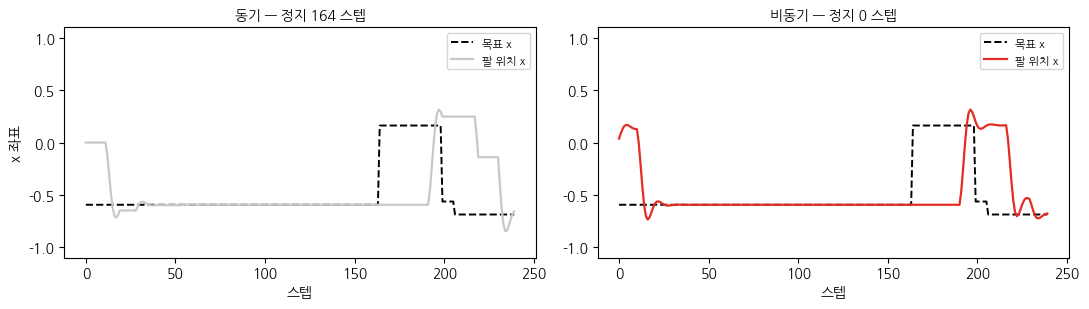

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
for a_, m, nm, c in [(ax[0], "sync", "동기", GREY), (ax[1], "async", "비동기", RED)]:
    r = rollout(m, jitter=12, n_ep=1, keep=True)
    path, g = r["traj"]
    a_.plot(g[:, 0], color="k", lw=1.4, ls="--", label="목표 x")
    a_.plot(path[:, 0], color=c, lw=1.6, label="팔 위치 x")
    a_.set_title(f"{nm} — 정지 {r['stall']:.0f} 스텝", fontsize=10)
    a_.set_xlabel("스텝"); a_.legend(fontsize=8); a_.set_ylim(-1.1, 1.1)
ax[0].set_ylabel("x 좌표")
plt.tight_layout(); plt.show()

### 다음 장으로
4부에서는 이 모델들을 실제로 학습시키고 평가하는 일을 다룬다. 데이터를 어떻게 모으고, 파인튜닝에서 무엇이 자주 어긋나며, 성능을 어떻게 재고, 시연을 넘어 어떻게 더 밀어 올릴지가 남았다.